# Aula 04 — Laços: `for`, `while` e Comprehensions

**Semana 2** | 50 min | Referências: McKinney (2012), *Python for Data Analysis* — Apêndice
*Python Language Essentials* (`kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md`)
e VanderPlas, *Python Data Science Handbook*, Cap. 1 (`kb/02_vanderplas_python_data_science_handbook/04_chapter-1-ipython-beyond-normal-python.md`)

Aula anterior: A03 (condicionais e decisão) · Próxima: A05 (funções e exceções)

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Repetir uma **regra de decisão** (Aula 03) sobre uma coleção inteira com `for`,
  usando `range`, `enumerate`, `zip` e desempacotamento de tuplas;
- Modelar **acumulações econômicas** (juros compostos mês a mês) com laços e acumuladores;
- Resolver **sistemas iterativos** (teia de aranha / ajuste oferta-demanda) com `while`,
  tolerância numérica `1e-6` e teto de iterações;
- Transformar coleções em uma linha com **list/dict comprehensions**
  (deflacionar preços, converter US$→R$/sc, filtrar carteiras);
- Controlar a repetição com `break` e `continue` (dados sujos, metas antecipadas).

In [1]:
# Setup — imports e padrões visuais usados na aula
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

# Taxa de referência da aula: Selic 13,9% a.a. (set/2026, BCB-SGS 1178)
i_aa = 0.139                       # taxa anual em decimal
i_m = (1 + i_aa) ** (1 / 12) - 1   # conversão GEOMÉTRICA para taxa mensal
print(f"Selic {i_aa:.1%} a.a. = {i_m:.4%} a.m.   (dividir por 12 daria {i_aa / 12:.4%} — errado)")

# Por que geométrica? Juros compostos: 1 ano = 12 multiplicações por (1 + i_m).
# Exigir (1 + i_m)**12 == 1 + i_aa dá i_m = (1 + i_aa)**(1/12) - 1 ≈ 1,0905% a.m.
# Dividir 13,9 por 12 (≈ 1,158%) SUPERESTIMA — erro clássico de ignorar a capitalização.

Selic 13.9% a.a. = 1.0905% a.m.   (dividir por 12 daria 1.1583% — errado)


## 1. O laço `for`: repetir a regra para todos

**Intuição econômica.** A política de crédito da Aula 03 decidiu **um** cliente. A realidade
da consultoria é uma **carteira**: dezenas de PMEs, a mesma régua. O `for` executa o corpo
uma vez **por elemento** da coleção — a regra é escrita uma vez, aplicada a todos.

Acompanhantes que você usará o curso inteiro:

| recurso | o que faz | exemplo |
|---|---|---|
| `range(a, b)` | inteiros de `a` até `b-1` | `for mes in range(1, 13):` — 12 meses |
| `enumerate(seq, start=1)` | devolve `(índice, elemento)` | `for i, c in enumerate(carteira, start=1):` |
| `zip(a, b)` | duas sequências em paralelo | `for pn, pi in zip(precos, ipcas):` |
| desempacotamento | tuplas viram variáveis | `for nome, score in pares:` |

In [2]:
# A regra de crédito da Aula 03 — agora para a carteira INTEIRA, sem copiar-e-colar
carteira = [
    ("Distribuidora Araguaia",    812),
    ("Laticínios Serra Dourada",  464),
    ("Empório Cerrado",           735),
    ("Oficina Anhanguera",        291),
    ("Padaria Sol Nascente",      503),
]

for i, (cliente, score) in enumerate(carteira, start=1):   # desempacota + numera
    if score >= 700:
        categoria, taxa = "A", 0.019
    elif score >= 450:
        categoria, taxa = "B", 0.034
    else:
        categoria, taxa = "C", 0.062
    print(f"Cliente {i}: {cliente:24s} score {score} -> {categoria} | {taxa:.2%} a.m.")

Cliente 1: Distribuidora Araguaia   score 812 -> A | 1.90% a.m.
Cliente 2: Laticínios Serra Dourada score 464 -> B | 3.40% a.m.
Cliente 3: Empório Cerrado          score 735 -> A | 1.90% a.m.
Cliente 4: Oficina Anhanguera       score 291 -> C | 6.20% a.m.
Cliente 5: Padaria Sol Nascente     score 503 -> B | 3.40% a.m.


### 1.1 Juros compostos mês a mês: o laço que reconstrói a fórmula

$$S_{t+1} = S_t \times (1 + i_m) \qquad\text{fórmula fechada: } S_T = S_0\,(1+i_m)^T$$

A fórmula fechada resume a iteração — mas a iteração **generaliza** para aportes, retiradas
e taxas variáveis, onde a fórmula fechada não serve. Comparar as duas é a prova de que o
laço está certo. Com $i_m \approx 1{,}0905\%$: R$ 1.000 → **R$ 1.139,00** em 12 meses.

In [3]:
# Juros compostos iterados: R$ 1.000 a 1,0905% a.m. durante 12 meses
saldo = 1_000.0
saldos = [saldo]                 # acumulador + histórico

for mes in range(1, 13):         # meses 1..12 — range(1, 13), NÃO range(1, 12)
    saldo = saldo * (1 + i_m)    # capitalização: o juro do mês entra no principal
    saldos.append(saldo)
    print(f"mês {mes:2d}: {brl(saldo)}")

# Prova de consistência: fórmula fechada x laço — devem bater exatamente
s_fechado = 1_000.0 * (1 + i_m) ** 12
print(f"\nfórmula fechada: {brl(s_fechado)} | diferença: {abs(saldo - s_fechado):.10f}")

mês  1: R$ 1.010,90
mês  2: R$ 1.021,93
mês  3: R$ 1.033,07
mês  4: R$ 1.044,34
mês  5: R$ 1.055,73
mês  6: R$ 1.067,24
mês  7: R$ 1.078,88
mês  8: R$ 1.090,64
mês  9: R$ 1.102,54
mês 10: R$ 1.114,56
mês 11: R$ 1.126,71
mês 12: R$ 1.139,00

fórmula fechada: R$ 1.139,00 | diferença: 0.0000000000


## 2. `while` + convergência: repetir até o modelo chegar lá

**Intuição econômica.** Nem todo processo econômico tem número de passos conhecido. Pergunta
de cliente: *"quanto tempo levo para dobrar R$ 1.000?"* — ninguém sabe a resposta de antemão;
o saldo cresce até **atingir** a meta. O `while` repete **enquanto** a condição for verdadeira.
E o mercado **procura** o equilíbrio: é o modelo da **teia de aranha** (*cobweb*) — a decisão
de plantio usa o preço **do ano anterior**, a oferta é defasada:

$$Q^d_t = a - bP_t \qquad Q^s_t = c + dP_{t-1} \;\;\Rightarrow\;\; P_{t+1} = \frac{a-c}{b} - \frac{d}{b}P_t$$

Com $a=100$, $b=2$, $c=-20$, $d=1$: $P_{t+1} = 60 - 0{,}5P_t$, equilíbrio $P^* = 40$.
Critério de parada numérico: $|P_{t+1} - P_t| < 10^{-6}$ — e SEMPRE um teto de iterações.

In [4]:
# while #1 — quanto tempo para DOBRAR o capital a 1,0905% a.m.?
saldo, meses = 1_000.0, 0
while saldo < 2 * 1_000:         # repete ENQUANTO não dobrou
    saldo *= 1 + i_m
    meses += 1

print(f"dobra em {meses} meses (~{meses / 12:.1f} anos)")
print(f"regra do 72: 72 / 13,9 = {72 / 13.9:.1f} anos — a aproximação de expediente")

dobra em 64 meses (~5.3 anos)
regra do 72: 72 / 13,9 = 5.2 anos — a aproximação de expediente


In [5]:
# while #2 — teia de aranha até o erro ser menor que 1e-6 (tolerância + teto)
p = 20.0                 # preço inicial fora do equilíbrio
tol = 1e-6               # tolerância — critério de convergência declarado
max_iter = 100           # teto de segurança: modelo divergente NÃO trava o notebook
historico = [p]

iteracao = 0
while iteracao < max_iter:
    p_novo = 60 - 0.5 * p          # dinâmica: P(t+1) = 60 - 0.5 P(t)
    erro = abs(p_novo - p)         # o quanto o preço se moveu nesta volta
    iteracao += 1
    p = p_novo
    historico.append(p)
    if erro < tol:
        break                      # convergiu — sair antes do teto

print(f"P* = {p:.6f} em {iteracao} iterações (erro final = {erro:.2e})")
print("trajetória:", [round(v, 3) for v in historico[:8]])

P* = 40.000000 em 26 iterações (erro final = 8.94e-07)
trajetória: [20.0, 50.0, 35.0, 42.5, 38.75, 40.625, 39.688, 40.156]


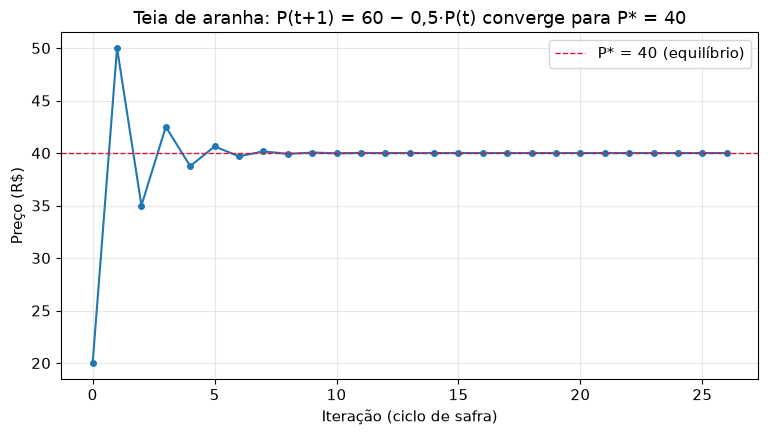

In [6]:
# Visualizar a convergência: oscilação em decaimento até assentar em P* = 40
fig, ax = plt.subplots()
ax.plot(range(len(historico)), historico, marker="o", markersize=4)
ax.axhline(40, color="crimson", linestyle="--", linewidth=1, label="P* = 40 (equilíbrio)")
ax.set_xlabel("Iteração (ciclo de safra)")
ax.set_ylabel("Preço (R$)")
ax.set_title("Teia de aranha: P(t+1) = 60 − 0,5·P(t) converge para P* = 40")
ax.legend()
plt.show()

### 2.1 Quando a teia NÃO converge: oferta mais elástica que a demanda

A convergência exige $|d/b| < 1$ (oferta menos reativa que a demanda). Se o produtor
**reage demais** ao preço observado ($d \ge b$), a oscilação **cresce** em vez de decair —
o clássico ciclo do porco/milho: plantar demais hoje é colher preço baixo amanhã.

> **Leitura econômica:** convergência = ajuste com parcimônia (preço estável); divergência =
> ciclo de *overreaction* — o mercado de porcos dos EUA nos anos 1930, padrão que ainda
> aparece em ciclos de plantio de commodities. O teto de iterações é o **diagnóstico do
> modelo**, não um detalhe de programação.

In [7]:
# Mesmo mercado com oferta hiper-reativa: Qs = -20 + 3·P(t-1) → P(t+1) = 60 - 1.5·P(t)
p = 20.0
iteracao = 0
while iteracao < 12:            # teto curto só para observar o comportamento
    p = 60 - 1.5 * p
    iteracao += 1
    print(f"iteração {iteracao:2d}: P = {p:12.2f}")

print("\n|d/b| = 1.5 > 1 → oscilação explosiva: o mercado NÃO converge (sem teto, laço infinito)")

# Confirmação da trajetória convergente anterior (|d/b| = 0.5 < 1): decaimento geométrico
print("convergente: |d/b| = 0.5 → erro cai ~metade por volta — por isso 26 iterações bastam")

iteração  1: P =        30.00
iteração  2: P =        15.00
iteração  3: P =        37.50
iteração  4: P =         3.75
iteração  5: P =        54.38
iteração  6: P =       -21.56
iteração  7: P =        92.34
iteração  8: P =       -78.52
iteração  9: P =       177.77
iteração 10: P =      -206.66
iteração 11: P =       369.99
iteração 12: P =      -494.99

|d/b| = 1.5 > 1 → oscilação explosiva: o mercado NÃO converge (sem teto, laço infinito)
convergente: |d/b| = 0.5 → erro cai ~metade por volta — por isso 26 iterações bastam


## 3. Comprehensions: transformar coleções em uma linha

**Intuição econômica.** A tarefa mais comum da consultoria é *aplicar a mesma transformação
a toda a série*: deflacionar preços pelo IPCA, converter US$/bushel para R$/saca, filtrar a
carteira. Laço explícito e comprehension são equivalentes — a comprehension é a "fórmula"
da repetição:

```python
resultado = []
for x in colecao:          # laço explícito (4 linhas)
    if condicao:
        resultado.append(expr)

resultado = [expr for x in colecao if condicao]   # comprehension (1 linha)
```

Duas transformações do dia a dia:

$$P^{real}_t = \frac{P^{nom}_t}{1 + \pi_t} \qquad
R\$/sc_{60} = \frac{US\$}{bu} \times \frac{60}{27{,}216} \times \text{câmbio}$$

(Deflação: $\pi_t$ = IPCA do mês em decimal. Soja: 1 bushel = 27,216 kg; câmbio 5,1253 —
BCB-SGS 1, 04/09/2026; soja CBOT ≈ US$ 12,9/bu em set/2026.)

In [8]:
# List comprehension + zip: deflacionar preços nominais pelo IPCA do mês
meses_n = ["mar", "abr", "mai", "jun"]
precos_nominais = [100.0, 104.0, 108.5, 111.0]
ipca_mensal = [0.0056, 0.0038, 0.0046, 0.0021]     # IPCA do mês, em decimal

precos_reais = [pn / (1 + pi) for pn, pi in zip(precos_nominais, ipca_mensal)]

for mes_n, pn, pr in zip(meses_n, precos_nominais, precos_reais):
    print(f"{mes_n}: nominal {brl(pn)} → real {brl(pr)}")

print("\no preço 'real' remove o IPCA do mês: é ele que permite comparar mar com jun")

mar: nominal R$ 100,00 → real R$ 99,44
abr: nominal R$ 104,00 → real R$ 103,61
mai: nominal R$ 108,50 → real R$ 108,00
jun: nominal R$ 111,00 → real R$ 110,77

o preço 'real' remove o IPCA do mês: é ele que permite comparar mar com jun


In [9]:
# List comprehension: converter soja US$/bushel → R$/saca de 60 kg — a conta do produtor
cambio = 5.1253                             # R$/US$ (04/09/2026)
precos_usd = [12.10, 12.45, 12.90, 13.20]   # US$/bushel (CBOT, ilustrativo)

precos_sc = [usd * 60 / 27.216 * cambio for usd in precos_usd]

print("US$/bu:", precos_usd)
print("R$/sc:", [round(v, 2) for v in precos_sc])
print(f"\nreferência: US$ 12,90/bu → {brl(12.90 * 60 / 27.216 * cambio)}/saca")

US$/bu: [12.1, 12.45, 12.9, 13.2]
R$/sc: [136.72, 140.67, 145.76, 149.15]

referência: US$ 12,90/bu → R$ 145,76/saca


In [10]:
# Comprehension com filtro (if): selecionar na carteira — o 'continue' vira 'if'
carteira_dict = [
    {"cliente": "Distribuidora Araguaia",   "score": 812},
    {"cliente": "Laticínios Serra Dourada", "score": 464},
    {"cliente": "Empório Cerrado",          "score": 735},
    {"cliente": "Oficina Anhanguera",       "score": 291},
    {"cliente": "Padaria Sol Nascente",     "score": 503},
]

clientes_a = [c["cliente"] for c in carteira_dict if c["score"] >= 700]
clientes_c = [c["cliente"] for c in carteira_dict if c["score"] < 450]

print("categoria A (score ≥ 700):", clientes_a)
print("categoria C (score < 450):", clientes_c)

print("\no 'if' da comprehension substitui o 'continue' do laço: quem não passa, não entra")

categoria A (score ≥ 700): ['Distribuidora Araguaia', 'Empório Cerrado']
categoria C (score < 450): ['Oficina Anhanguera']

o 'if' da comprehension substitui o 'continue' do laço: quem não passa, não entra


### 3.1 Dict comprehension: tabelas de mapeamento

O dict comprehension constrói a **tabela de decisão** que a Aula 03 prometeu: quando a
escada de `match` cresce, vira **dados** — não código. E `.get(chave, default)` protege
contra o dado sujo.

In [11]:
# Dict comprehension #1: juros acumulados por prazo de aplicação
prazos = [1, 3, 6, 12]
juros_acumulados = {n: (1 + i_m) ** n - 1 for n in prazos}

for n, j in juros_acumulados.items():
    print(f"{n:2d} mês(es): juro acumulado {j:.2%}")

print(f"\nchecagem: 12 meses devolve a própria Selic — {(1 + i_m) ** 12 - 1:.2%}")

 1 mês(es): juro acumulado 1.09%
 3 mês(es): juro acumulado 3.31%
 6 mês(es): juro acumulado 6.72%
12 mês(es): juro acumulado 13.90%

checagem: 12 meses devolve a própria Selic — 13.90%


In [12]:
# Dict comprehension #2: mapa CNAE (cumprindo a promessa da Aula 03)
cnae_mapa = {
    **{"A": "Agropecuária"},                       # **espalha ('merge') os dicts
    **{letra: "Indústria" for letra in "BCDE"},     # comprehension para chaves em série
    "F": "Construção",
    "G": "Comércio",
    **{letra: "Serviços" for letra in "HIJKLMN"},
}

for secao in ["A", "G", "J", "X"]:
    print(f"Seção {secao}: {cnae_mapa.get(secao, 'Seção inválida')}")   # .get com default

print("\nchaves repetidas em dict comprehension SOBRESCREVEM — a última ganha. Conferir len()")

Seção A: Agropecuária
Seção G: Comércio
Seção J: Serviços
Seção X: Seção inválida

chaves repetidas em dict comprehension SOBRESCREVEM — a última ganha. Conferir len()


### 3.2 Generators: iteração preguiçosa

Parênteses em vez de colchetes: nada é calculado até ser pedido (*lazy evaluation*).
Consome-se **uma única vez** — ideal para sequências longas (séries diárias de 10 anos)
sem alocar a lista inteira na memória. Voltaremos a eles em séries temporais (Aula 17).

In [13]:
# Generator expression: produz valores sob demanda
juros_gen = ((1 + i_m) ** n - 1 for n in [1, 3, 6, 12])

print("objeto:", juros_gen)                 # ainda NÃO calculou nada!
print("next():", f"{next(juros_gen):.4%}")  # pede UM valor por vez
print("soma do resto:", f"{sum(juros_gen):.4%}")   # consome o restante

# list(juros_gen) agora devolveria [] — gerador esgota
print("esgotado:", list(juros_gen))

objeto: <generator object <genexpr> at 0x10c156810>
next(): 1.0905%
soma do resto: 23.9312%
esgotado: []


### 3.3 Laço vs. comprehension vs. vetorizado: cronometrando

O laço explícito é a ferramenta **didática**, não a rápida. Cronometre a soma de 100 mil
números de três formas — e guarde o resultado para a Aula 07 (NumPy).

In [14]:
# Timing: for com acumulador x sum() nativo x NumPy (Aula 07)
numeros = list(np.random.default_rng(42).uniform(0, 1, 100_000))

t0 = time.perf_counter()
total = 0.0
for x in numeros:
    total += x
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
total_sum = sum(numeros)               # função nativa: o laço roda em C
t_sum = time.perf_counter() - t0

arr = np.asarray(numeros)              # conversão + primeiro .sum() (aquecimento)
_ = arr.sum()
t0 = time.perf_counter()
total_np = arr.sum()                   # vetorizado, em array pronto
t_np = time.perf_counter() - t0

print(f"for com acumulador : {t_loop * 1000:7.2f} ms  (total {total:,.2f})")
print(f"sum() nativo       : {t_sum * 1000:7.2f} ms  (total {total_sum:,.2f})")
print(f"NumPy .sum()       : {t_np * 1000:7.3f} ms  (total {total_np:,.2f})  <- padrão da Aula 07")

print(f"\nmesma resposta: {abs(total - total_np) < 1e-6} — velocidade diferente, resultado idêntico")

for com acumulador :    3.84 ms  (total 50,062.49)
sum() nativo       :    2.06 ms  (total 50,062.49)
NumPy .sum()       :   0.033 ms  (total 50,062.49)  <- padrão da Aula 07

mesma resposta: True — velocidade diferente, resultado idêntico


## 4. `break` e `continue`: pular o lixo, parar na meta

**Intuição econômica.** Dados de campo chegam sujos: receita `None` (não informada), valor
negativo (lançamento estornado). `continue` **pula** a volta atual — o filtro de qualidade.
`break` **encerra** o laço — o critério de parada antecipado (meta atingida antes do prazo).
Ambos vêm do Apêndice de McKinney (*for loops*).

In [15]:
# continue: filtrar dados sujos antes de somar (None ≠ 0 — lembrete da Aula 03)
receitas = [12_500, None, 9_800, -400, 15_300]   # None = não informado; -400 = estorno

total = 0.0
for r in receitas:
    if r is None:      # ausência de dado: pulamos, NÃO tratamos como zero
        continue
    if r < 0:          # estorno não entra na receita bruta
        continue
    total += r

print(f"receita bruta válida: {brl(total)}")

# Prova: o mesmo filtro em uma comprehension (comum na limpeza de planilhas)
total_comp = sum(r for r in receitas if r is not None and r > 0)
print(f"mesma conta com comprehension: {brl(total_comp)}")

receita bruta válida: R$ 37.600,00
mesma conta com comprehension: R$ 37.600,00


In [16]:
# break: parar assim que a meta for atingida — iterar além é desperdício
saldo = 1_000.0
meta = 1_500.0

for mes in range(1, 121):          # até 10 anos, mas...
    saldo *= 1 + i_m
    if saldo >= meta:
        break                      # ...a meta chega antes — parar aqui

print(f"meta de {brl(meta)} atingida no mês {mes} com {brl(saldo)}")
print("sem o break, o laço iteraria 120 vezes desnecessárias")

meta de R$ 1.500,00 atingida no mês 38 com R$ 1.510,05
sem o break, o laço iteraria 120 vezes desnecessárias


## 📝 Exercícios

Tente resolver antes de abrir a célula de solução. Contexto: consultoria financeira e de
mercado da OIKOS — poupança de cliente PME, ciclos de preço agrícola e conversão de
preços internacionais.

### Exercício 1 — Juros compostos com aporte mensal

Um cliente aplica **R$ 1.000** hoje e consegue aportar **R$ 200 todo mês**, à taxa da aula
(Selic 13,9% a.a. → $i_m \approx 1{,}0905\%$ a.m.). Usando um laço `for` de 24 meses,
calcule o **saldo final**. Imprima com `brl()`.

*Ordem dentro do laço: capitalizar primeiro, aportar depois — o aporte do mês também rende
a partir do mês seguinte.*

In [17]:
# EXERCÍCIO 1 — seu código aqui


In [18]:
# SOLUÇÃO 1
saldo = 1_000.0     # saldo inicial
aporte = 200.0      # depósito todo mês

for mes in range(1, 25):                 # 24 meses = range(1, 25)
    saldo = saldo * (1 + i_m) + aporte   # capitaliza PRIMEIRO, aporta DEPOIS

print(f"Saldo final: {brl(saldo)}")

# Resposta: R$ 6.750,29 — sem os aportes, os mesmos R$ 1.000 renderiam R$ 1.297,32

Saldo final: R$ 6.750,29


### Exercício 2 — Teia de aranha: outro mercado

Mercado com demanda $Q^d = 80 - P$ e oferta defasada $Q^s = -10 + 0{,}5\,P_{t-1}$. A
dinâmica de preço resultante é:

$$P_{t+1} = 90 - 0{,}5\,P_t$$

Partindo de $P_0 = 30$, itere com `while` até $|P_{t+1} - P_t| < 10^{-6}$ (teto de 100
iterações) e imprima o equilíbrio $P^*$ e o número de iterações.

*Dica: a estrutura é idêntica à da Seção 2 — só muda a dinâmica e o preço inicial.*

In [19]:
# EXERCÍCIO 2 — seu código aqui


In [20]:
# SOLUÇÃO 2
p = 30.0            # preço inicial
tol = 1e-6
max_iter = 100

iteracao = 0
while iteracao < max_iter:
    p_novo = 90 - 0.5 * p     # P(t+1) = 90 - 0.5 P(t)
    erro = abs(p_novo - p)
    iteracao += 1
    p = p_novo
    if erro < tol:
        break

print(f"Convergiu para P* = {p:.6f} em {iteracao} iterações (erro final = {erro:.2e})")

# Resposta: P* = 60,000000 em 27 iterações — coeficiente 0,5 < 1 garante convergência

Convergiu para P* = 60.000000 em 27 iterações (erro final = 6.71e-07)


### Exercício 3 — Soja: US$/bushel → R$/saca, com filtro

A lista abaixo traz cotações de soja (US$/bushel). Com câmbio de **R$ 5,1253/US$**, use uma
**list comprehension** para converter todas para R$/saca de 60 kg (1 bu = 27,216 kg) e uma
segunda comprehension para filtrar **apenas as cotações acima de US$ 12,50/bu**.

*Fórmula: `usd * 60 / 27.216 * cambio` — a mesma da Seção 3.*

In [21]:
# EXERCÍCIO 3 — seu código aqui
precos_usd = [12.10, 12.45, 12.90, 13.20]   # US$/bushel (CBOT)
cambio = 5.1253                             # R$/US$


In [22]:
# SOLUÇÃO 3
precos_usd = [12.10, 12.45, 12.90, 13.20]   # US$/bushel (CBOT)
cambio = 5.1253                             # R$/US$

precos_sc = [usd * 60 / 27.216 * cambio for usd in precos_usd]
caros = [usd * 60 / 27.216 * cambio for usd in precos_usd if usd > 12.50]

print("R$/sc de todos: ", [round(v, 2) for v in precos_sc])
print("R$/sc acima de US$ 12,50:", [round(v, 2) for v in caros])

# Resposta: [136.72, 140.67, 145.76, 149.15]; o filtro mantém [145.76, 149.15]

R$/sc de todos:  [136.72, 140.67, 145.76, 149.15]
R$/sc acima de US$ 12,50: [145.76, 149.15]


### Exercício 4 — Tabela de cargas tributárias com dict

A escada de `match` da Aula 03 cresceu: regimes viram **tabela**. Com o dict abaixo, use
`.get()` para imprimir a carga de cada regime da lista — e `regime não cadastrado` para o
que não está na tabela (`mei`), **sem quebrar** o código.

```python
cargas = {"simples": 0.05, "presumido": 0.085, "real": 0.065}
```

*Dica: `.get(regime)` devolve `None` quando a chave não existe; teste
`if carga is not None` (truthiness da Aula 03 — carga 0% é dado legítimo, não ausência).*

In [23]:
# EXERCÍCIO 4 — seu código aqui
cargas = {"simples": 0.05, "presumido": 0.085, "real": 0.065}


In [24]:
# SOLUÇÃO 4
cargas = {"simples": 0.05, "presumido": 0.085, "real": 0.065}

for regime in ["simples", "presumido", "real", "mei"]:
    carga = cargas.get(regime)
    rotulo = f"{carga:.1%}" if carga is not None else "regime não cadastrado"
    print(f"{regime:10s} -> {rotulo}")

# Resposta: simples 5.0% · presumido 8.5% · real 6.5% · mei → regime não cadastrado

simples    -> 5.0%
presumido  -> 8.5%
real       -> 6.5%
mei        -> regime não cadastrado


## 📌 Resumo & para casa

- `for` percorre coleções: a **regra de decisão da Aula 03 agora roda para a carteira
  inteira** — `range` conta meses, `enumerate` numera, `zip` alinha duas séries, tuplas
  desempacotam em variáveis.
- Juros compostos são um laço com memória: $S_{t+1} = S_t(1+i_m)$; a conversão anual→mensal
  é **geométrica** ($i_m = (1+i_a)^{1/12} - 1$), nunca dividir por 12.
- `while` repete **até convergir**: tolerância explícita (`1e-6`) + teto de iterações —
  a teia de aranha $P_{t+1} = 60 - 0{,}5P_t$ converge para $P^* = 40$; com oferta mais
  elástica que a demanda, diverge (o teto é o diagnóstico).
- Comprehension = a repetição em uma linha: `[expr for x in col if cond]` — deflacionar
  preços, converter US$→R$/sc, filtrar a carteira; `dict comprehension` constrói tabelas
  de mapeamento (o `match` da Aula 03 vira dados).
- `continue` pula o dado sujo (`None`, negativo — `None` ≠ 0!); `break` para na meta —
  iterar além do necessário é desperdício.
- Laço explícito é didático, não rápido: `sum()` e NumPy (Aula 07) são ordens de grandeza
  mais velozes na soma de 100 mil números.

**Para casa:** refaça o Exercício 1 com **retirada** mensal de R$ 150 (o saldo pode
negativar?) e o Exercício 2 trocando $P_0$ para 55 e para 60 — o que acontece com o número
de iterações quando você parte do equilíbrio?

**Próxima aula (A05):** funções e exceções — a regra de crédito vira
`classificar_cliente(score)`, reutilizável e testável; o laço chama a função.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/15_appendix-python-language-essentials.md`
  — seções **for loops** (com `continue`/`break`), **while loops**,
  **List, Set, and Dict Comprehensions** e **Generators**.
- `kb/02_vanderplas_python_data_science_handbook/04_chapter-1-ipython-beyond-normal-python.md`
  — VanderPlas, Cap. 1 (comprehensions e loop vs. vetorizado).